# Customer Intelligence System using Classification, Ensemble Learning & Clustering


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, DBSCAN
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, silhouette_score
try:
    from xgboost import XGBClassifier
    xgb_available = True
except:
    xgb_available = False

# Load dataset
df = pd.read_csv("/content/Country-data .csv")
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


## Data Preprocessing

In [3]:
# Check missing values
print(df.isnull().sum())

# Encode country names
le = LabelEncoder()
df['country_code'] = le.fit_transform(df['country'])

# Feature scaling
features = df.drop('country', axis=1)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

scaled_df = pd.DataFrame(scaled_features, columns=features.columns)
scaled_df.head()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,country_code
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180,-1.721710
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623,-1.700967
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376,-1.680223
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268,-1.659480
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817,-1.638736


## K-Means Clustering

In [4]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(scaled_features)

print("Silhouette Score:", silhouette_score(scaled_features, df['KMeans_Cluster']))

df[['country','KMeans_Cluster']].head()

Silhouette Score: 0.24043690533753959


,country,KMeans_Cluster
0,Afghanistan,1
1,Albania,2
2,Algeria,2
3,Angola,1
4,Antigua and Barbuda,2


## DBSCAN Clustering

In [5]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(scaled_features)

print(df['DBSCAN_Cluster'].value_counts())

DBSCAN_Cluster
 0    91
-1    58
 1    18
Name: count, dtype: int64


## Create Target Variable for Classification

In [7]:
# High-income country prediction
df['Target'] = (df['income'] > df['income'].median()).astype(int)

X = df.drop(['country','Target'], axis=1)
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Random Forest Classifier

In [8]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## XGBoost Classifier

In [9]:
if xgb_available:
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    )

    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)

    print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
    print(classification_report(y_test, xgb_pred))
else:
    print("Install xgboost using: pip install xgboost")

XGBoost Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        16

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## Feature Importance

           Feature  Importance
4           income    0.360262
8             gdpp    0.290938
0       child_mort    0.122584
6       life_expec    0.088522
7        total_fer    0.061919
10  KMeans_Cluster    0.019858
5        inflation    0.017991
1          exports    0.017850
2           health    0.008726
3          imports    0.006578


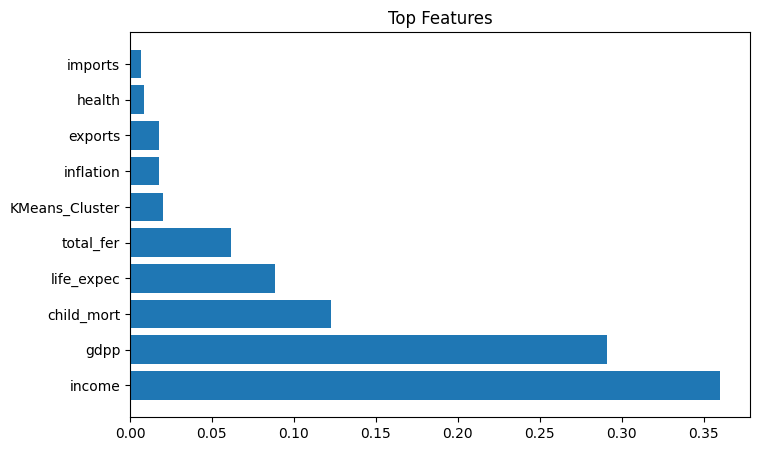

In [10]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

plt.figure(figsize=(8,5))
plt.barh(importance['Feature'][:10], importance['Importance'][:10])
plt.title("Top Features")
plt.show()

## Conclusion:
The machine learning models successfully analyzed and classified countries based on socio-economic indicators. The results show that these features are effective in identifying development and income-related patterns across countries.

## Final Insights
- K-Means segments countries into groups.
- DBSCAN detects density-based clusters and outliers.
- Random Forest provides robust ensemble classification.
- XGBoost improves predictive performance.
- Clustering + classification together form a Customer Intelligence System.